Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 50
Starting parallel Monte Carlo with 50 iterations using 8 proce

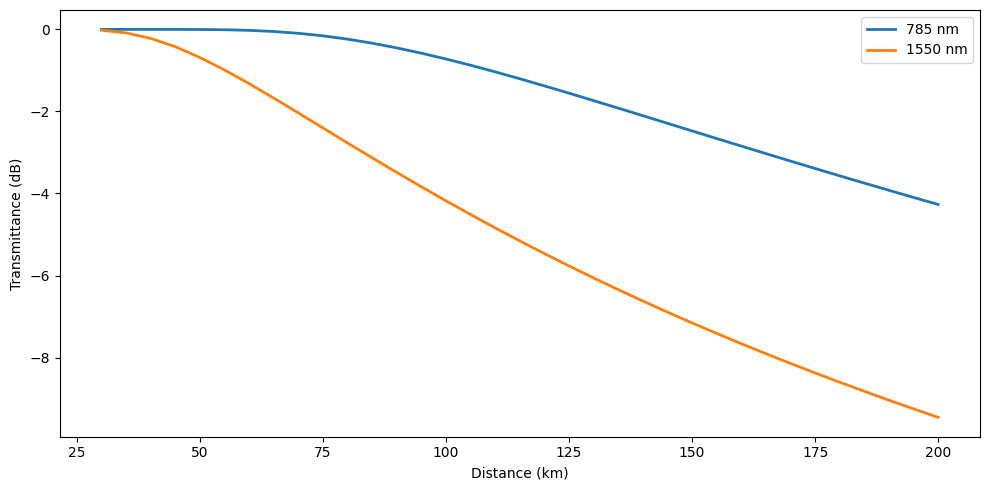

Saved figure: transmittance_comparison_v2.png


In [1]:
from quick import elliptic_beam_model
import numpy as np
import matplotlib.pyplot as plt

# Shared params
W0 = 0.044
beta = 0
Cn2 = 0
n0 = 0
aperture_radius = 0.55
n_samples = 50
distances = np.arange(30, 201, 5) * 1e3

model = elliptic_beam_model()

# --- 785 nm ---
wavelength = 785
k = 2 * np.pi / (wavelength * 1e-9)
mean_transmittance_785 = []
for L in distances:
    h = L
    model.set_params(k, Cn2, n0, W0, h, L, aperture_radius, beta)
    result = model.run_monte_carlo_parallel(n_samples)
    mean_transmittance_785.append(np.mean(result))
mean_transmittance_785 = np.array(mean_transmittance_785)

# --- 1550 nm ---
wavelength = 1550
k = 2 * np.pi / (wavelength * 1e-9)
mean_transmittance_1550 = []
for L in distances:
    h = L
    model.set_params(k, Cn2, n0, W0, h, L, aperture_radius, beta)
    result = model.run_monte_carlo_parallel(n_samples)
    mean_transmittance_1550.append(np.mean(result))
mean_transmittance_1550 = np.array(mean_transmittance_1550)

# --- Save arrays so you don't have to re-run the sim ---
np.save('mean_transmittance_785.npy', mean_transmittance_785)
np.save('mean_transmittance_1550.npy', mean_transmittance_1550)
np.save('distances.npy', distances)
print("Saved: mean_transmittance_785.npy, mean_transmittance_1550.npy, distances.npy")

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(distances / 1e3, 10 * np.log10(mean_transmittance_785),
         linewidth=2, label='785 nm')
plt.plot(distances / 1e3, 10 * np.log10(mean_transmittance_1550),
         linewidth=2, label='1550 nm')
plt.xlabel('Distance (km)')
plt.ylabel('Transmittance (dB)')
plt.legend()
plt.tight_layout()
plt.savefig('transmittance_comparison_v2.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved figure: transmittance_comparison_v2.png")

In [1]:
from quick import elliptic_beam_model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters for ground-to-ground link
a_r = 0.55                                      # receive aperture [m]
W0 = 0.044                                      # initial beam waist [m]
beta = 0.7                                      # extinction coefficient

k = 2 * np.pi / (785e-9)                        # wavelength: 785 nm

# From Table E2 in the paper - Night conditions
night_conditions = {
    'Night 1 (Clear)': {'Cn2': 1.12e-16, 'n0': 0.61},
    'Night 2 (Slightly Foggy)': {'Cn2': 5.50e-16, 'n0': 3.00},
    'Night 3 (Moderately Foggy)': {'Cn2': 1.10e-15, 'n0': 6.10}
}

# From Table E2 - Day conditions
day_conditions = {
    'Day 1 (Not Windy)': {'Cn2': 1.64e-16, 'n0': 0.01},
    'Day 2 (Moderately Windy)': {'Cn2': 8.00e-16, 'n0': 0.05},
    'Day 3 (Windy)': {'Cn2': 1.60e-15, 'n0': 0.10}
}

# Distance range
distances = np.arange(30, 150, 10) * 1e3  # 30 km to 150 km in 10 km increments

print("=" * 80)
print("Ground-to-Ground Link Transmittance Analysis")
print("=" * 80)
print(f"Parameters: W0={W0} m, a_r={a_r} m, λ=785 nm, β={beta}")
print(f"Distance range: {distances[0]/1e3:.0f} km to {distances[-1]/1e3:.0f} km")
print(f"Total simulations: {len(night_conditions) + len(day_conditions)} conditions × {len(distances)} distances = {(len(night_conditions) + len(day_conditions)) * len(distances)}")
print("=" * 80)

# Function to compute mean transmittance for a given distance and condition
def compute_mean_transmittance(L, Cn2, n0, num_samples=1000):
    h = L  # Ground-to-ground: h = L
    model = elliptic_beam_model()
    model.set_params(k, Cn2, n0, W0, h, L, a_r, beta)
    
    result = model.run_monte_carlo_parallel(num_samples)
    return np.mean(result), np.std(result)

# Storage for CSV export
all_data = []

# ========== NIGHT CONDITIONS ==========
print("\nProcessing NIGHT conditions...")
night_results = {}

for condition_name, params in night_conditions.items():
    print(f"\n{condition_name}:")
    mean_trans = []
    std_trans = []
    
    for L in distances:
        print(f"  {L/1e3:.0f} km", end=' ')
        mean_t, std_t = compute_mean_transmittance(L, params['Cn2'], params['n0'])
        mean_trans.append(mean_t)
        std_trans.append(std_t)
        print(f"T={mean_t:.4f}")
        
        # Store for CSV
        all_data.append({
            'Condition_Type': 'Night',
            'Condition_Name': condition_name,
            'Distance_km': L/1e3,
            'Cn2': params['Cn2'],
            'n0': params['n0'],
            'Mean_Transmittance': mean_t,
            'Std_Transmittance': std_t
        })
    
    night_results[condition_name] = {
        'mean': np.array(mean_trans),
        'std': np.array(std_trans)
    }

# SAVE NIGHT PLOT
print("\nCreating NIGHT plot...")
fig1, ax1 = plt.subplots(figsize=(10, 6))
colors_night = ['blue', 'cyan', 'navy']
for (condition_name, data), color in zip(night_results.items(), colors_night):
    ax1.plot(distances/1e3, data['mean'], 'o-', color=color, linewidth=2, 
             markersize=6, label=condition_name)
    ax1.fill_between(distances/1e3, 
                      data['mean'] - data['std'], 
                      data['mean'] + data['std'],
                      color=color, alpha=0.2)

ax1.set_xlabel('Distance (km)', fontsize=12)
ax1.set_ylabel('Mean Transmittance', fontsize=12)
ax1.set_title('Night-Time Ground-to-Ground Link', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('ground_to_ground_NIGHT.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ground_to_ground_NIGHT.png")
plt.close()

# ========== DAY CONDITIONS ==========
print("\n" + "=" * 80)
print("Processing DAY conditions...")
day_results = {}

for condition_name, params in day_conditions.items():
    print(f"\n{condition_name}:")
    mean_trans = []
    std_trans = []
    
    for L in distances:
        print(f"  {L/1e3:.0f} km", end=' ')
        mean_t, std_t = compute_mean_transmittance(L, params['Cn2'], params['n0'])
        mean_trans.append(mean_t)
        std_trans.append(std_t)
        print(f"T={mean_t:.4f}")
        
        # Store for CSV
        all_data.append({
            'Condition_Type': 'Day',
            'Condition_Name': condition_name,
            'Distance_km': L/1e3,
            'Cn2': params['Cn2'],
            'n0': params['n0'],
            'Mean_Transmittance': mean_t,
            'Std_Transmittance': std_t
        })
    
    day_results[condition_name] = {
        'mean': np.array(mean_trans),
        'std': np.array(std_trans)
    }

# SAVE DAY PLOT
print("\nCreating DAY plot...")
fig2, ax2 = plt.subplots(figsize=(10, 6))
colors_day = ['orange', 'red', 'darkred']
for (condition_name, data), color in zip(day_results.items(), colors_day):
    ax2.plot(distances/1e3, data['mean'], 's-', color=color, linewidth=2,
             markersize=6, label=condition_name)
    ax2.fill_between(distances/1e3,
                      data['mean'] - data['std'],
                      data['mean'] + data['std'],
                      color=color, alpha=0.2)

ax2.set_xlabel('Distance (km)', fontsize=12)
ax2.set_ylabel('Mean Transmittance', fontsize=12)
ax2.set_title('Day-Time Ground-to-Ground Link', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
ax2.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('ground_to_ground_DAY.png', dpi=300, bbox_inches='tight')
print("✓ Saved: ground_to_ground_DAY.png")
plt.close()

# SAVE ALL DATA TO CSV
df = pd.DataFrame(all_data)
df.to_csv('ground_to_ground_results.csv', index=False)
print("\n✓ Saved: ground_to_ground_results.csv")

print("\n" + "=" * 80)
print("Analysis complete!")
print("Files saved:")
print("  - ground_to_ground_NIGHT.png")
print("  - ground_to_ground_DAY.png")
print("  - ground_to_ground_results.csv")
print("=" * 80)

Ground-to-Ground Link Transmittance Analysis
Parameters: W0=0.044 m, a_r=0.55 m, λ=785 nm, β=0.7
Distance range: 30 km to 140 km
Total simulations: 6 conditions × 12 distances = 72

Processing NIGHT conditions...

Night 1 (Clear):
  30 km Starting parallel Monte Carlo with 1000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 1000
T=0.2383
  40 km Starting parallel Monte Carlo with 1000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 1000
T=0.0961
  50 km Starting parallel Monte Carlo with 1000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 1000
T=0.0392
  60 km Starting parallel Monte Carlo with 1000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 1000
T=0.0169
  70 km Starting parallel Monte Carlo with 1000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 1000
T=0

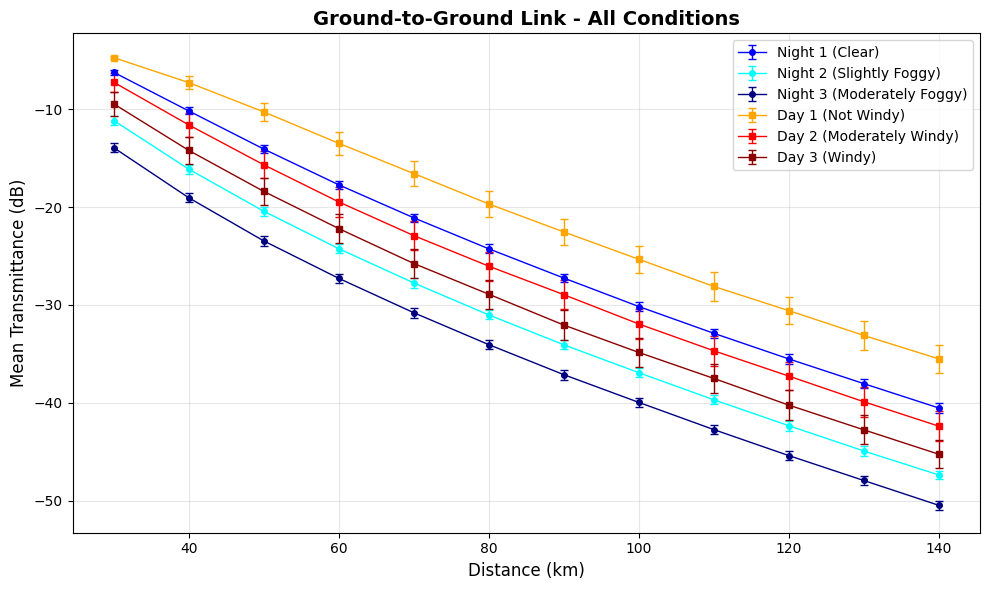

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('ground_to_ground_results.csv')

fig, ax = plt.subplots(figsize=(10, 6))

colors_night = ['blue', 'cyan', 'navy']
night_conditions = df[df['Condition_Type'] == 'Night']['Condition_Name'].unique()

for condition, color in zip(night_conditions, colors_night):
    data = df[df['Condition_Name'] == condition]
    mean_dB = 10*np.log10(data['Mean_Transmittance'])
    err_dB = 10*np.log10(1 + data['Std_Transmittance']/data['Mean_Transmittance'])
    ax.errorbar(data['Distance_km'], mean_dB, yerr=err_dB,
                fmt='o-', color=color, linewidth=1, markersize=4, 
                capsize=3, capthick=1, label=condition)

colors_day = ['orange', 'red', 'darkred']
day_conditions = df[df['Condition_Type'] == 'Day']['Condition_Name'].unique()

for condition, color in zip(day_conditions, colors_day):
    data = df[df['Condition_Name'] == condition]
    mean_dB = 10*np.log10(data['Mean_Transmittance'])
    err_dB = 10*np.log10(1 + data['Std_Transmittance']/data['Mean_Transmittance'])
    ax.errorbar(data['Distance_km'], mean_dB, yerr=err_dB,
                fmt='s-', color=color, linewidth=1, markersize=4,
                capsize=3, capthick=1, label=condition)

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Mean Transmittance (dB)', fontsize=12)
ax.set_title('Ground-to-Ground Link - All Conditions', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.024603
Using 65 bins for histogram.
Saved fig as : 72km_data\night1_72km.png


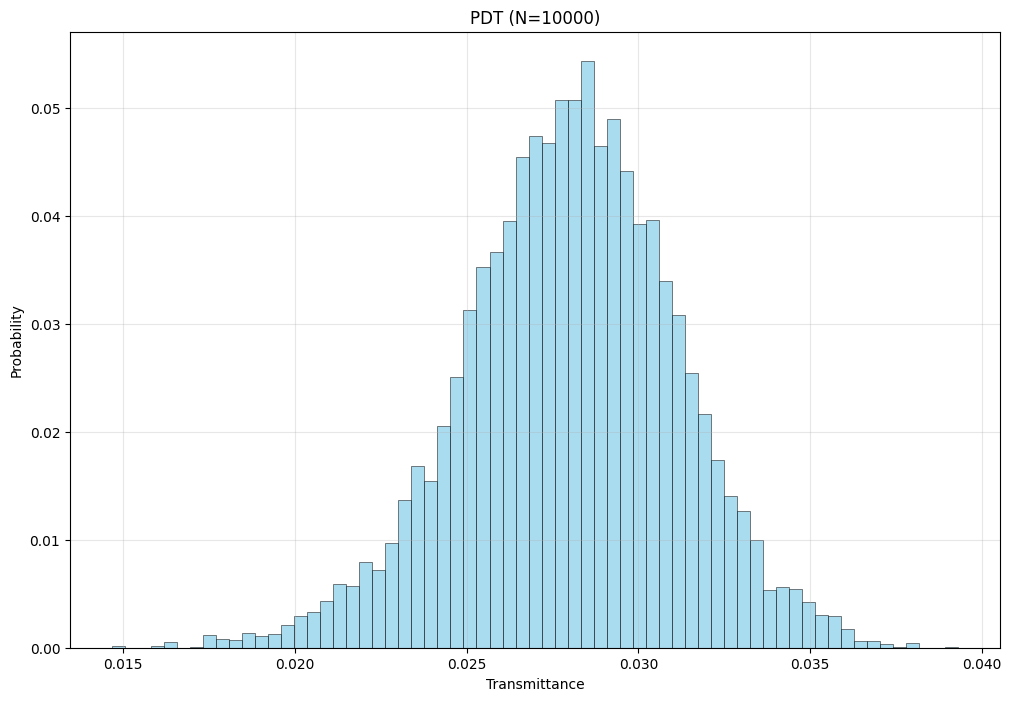

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.005662
Using 67 bins for histogram.
Saved fig as : 72km_data\night2_72km.png


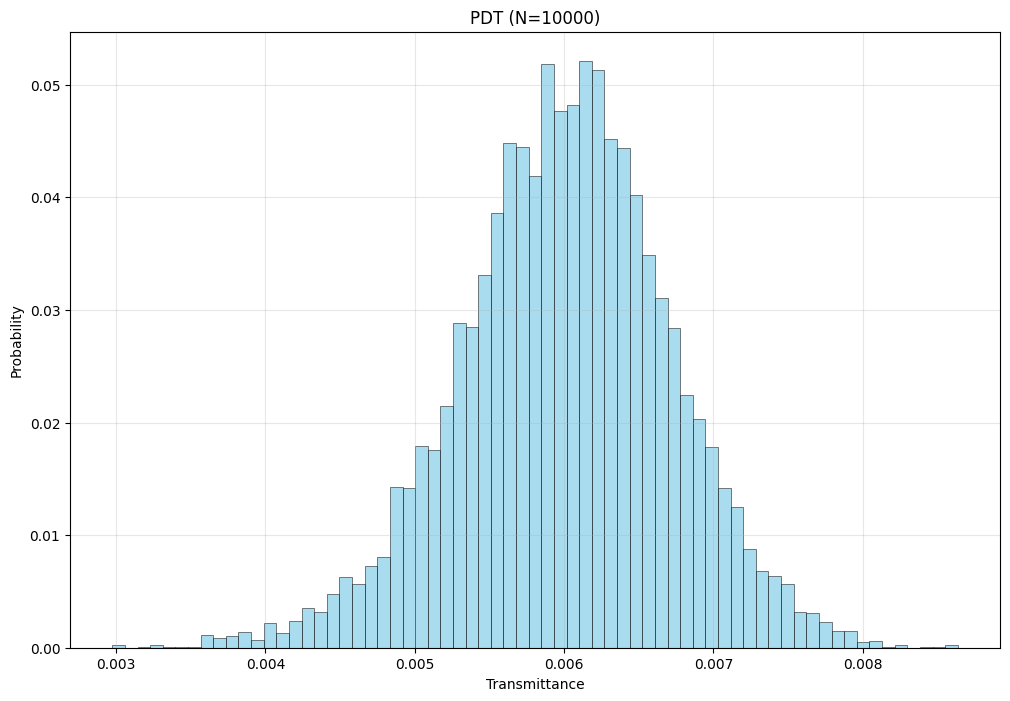

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.002849
Using 68 bins for histogram.
Saved fig as : 72km_data\night3_72km.png


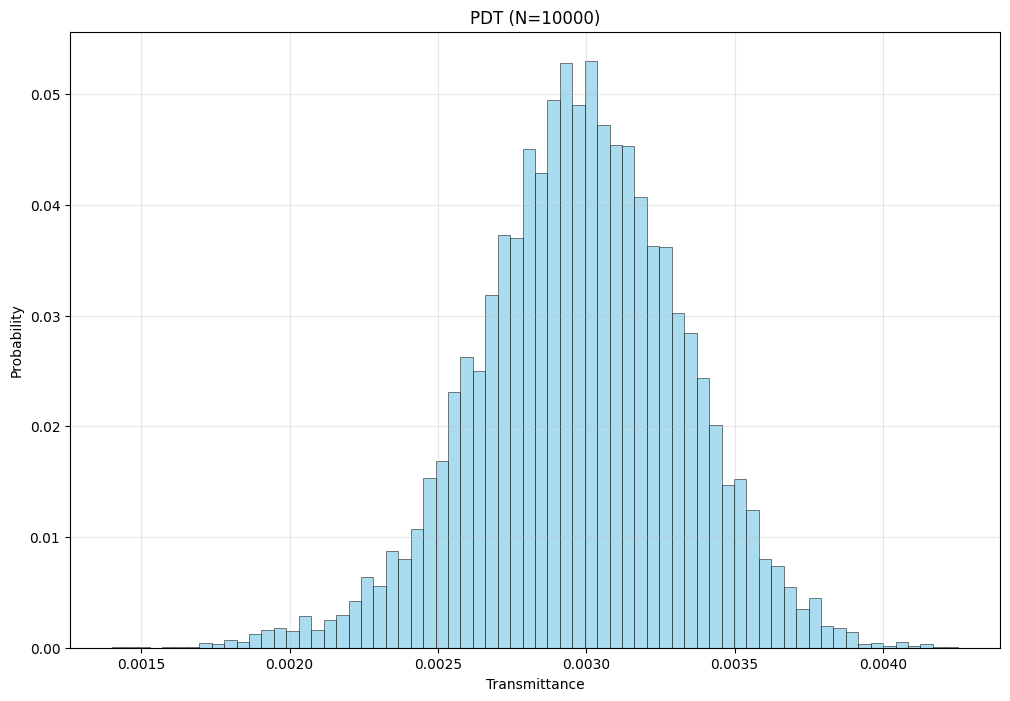

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.146715
Using 40 bins for histogram.
Saved fig as : 72km_data\day1_72km.png


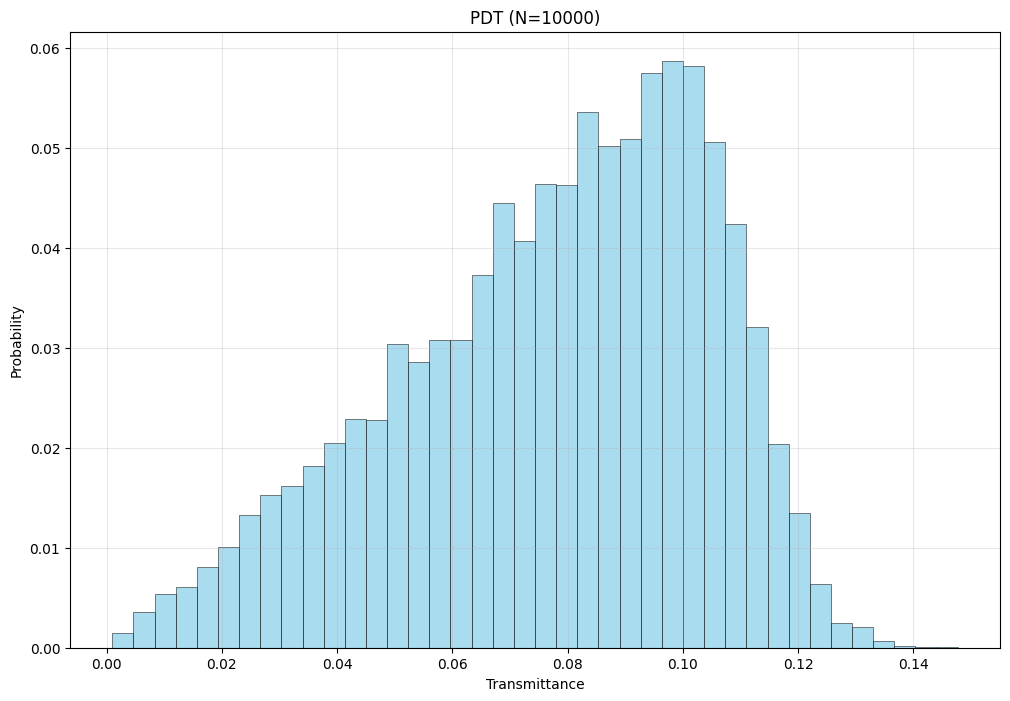

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.037663
Using 34 bins for histogram.
Saved fig as : 72km_data\day2_72km.png


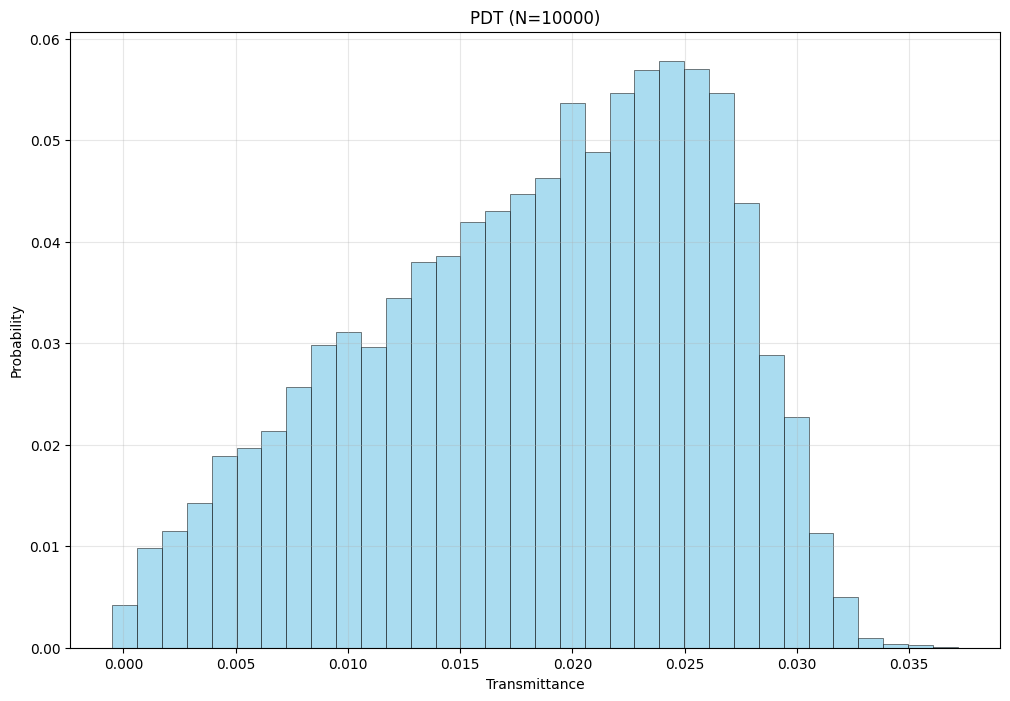

Starting parallel Monte Carlo with 10000 iterations using 8 processes...
Parallel Monte Carlo simulation completed! Total iterations: 10000
Data range: 0.019118
Using 33 bins for histogram.
Saved fig as : 72km_data\day3_72km.png


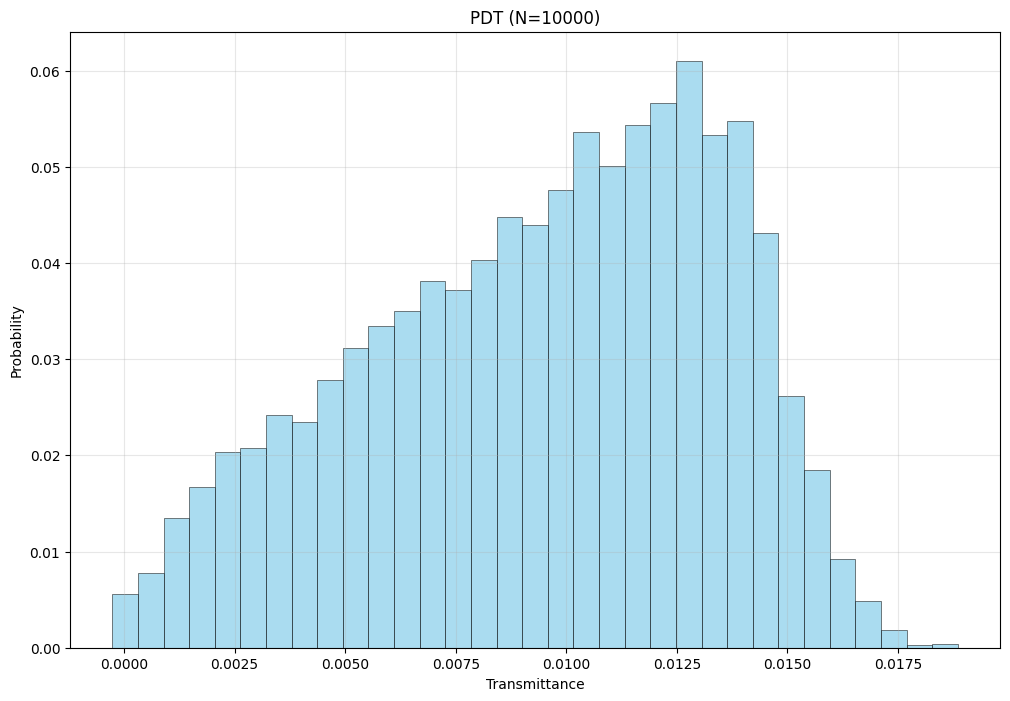

In [1]:
from quick import elliptic_beam_model
import numpy as np
import os

W0 = 0.044
a_r = 0.55
beta = 0.3
k = 2 * np.pi / (785e-9)
L = 72 * 1e3
h = L

output_dir = "72km_data"
os.makedirs(output_dir, exist_ok=True)

conditions = {
    'night1': {'Cn2': 1.12e-16, 'n0': 0.61, 'desc': 'Night 1 (Clear)'},
    'night2': {'Cn2': 5.50e-16, 'n0': 3.00, 'desc': 'Night 2 (Slightly Foggy)'},
    'night3': {'Cn2': 1.10e-15, 'n0': 6.10, 'desc': 'Night 3 (Moderately Foggy)'},
    'day1': {'Cn2': 1.64e-16, 'n0': 0.01, 'desc': 'Day 1 (Not Windy)'},
    'day2': {'Cn2': 8.00e-16, 'n0': 0.05, 'desc': 'Day 2 (Moderately Windy)'},
    'day3': {'Cn2': 1.60e-15, 'n0': 0.10, 'desc': 'Day 3 (Windy)'}
}

num_samples = 10000

for condition_name, params in conditions.items():
    model = elliptic_beam_model()
    model.set_params(k, params['Cn2'], params['n0'], W0, h, L, a_r, beta)
    result = model.run_monte_carlo_parallel(num_samples)
    
    filename = f"{condition_name}_{int(L/1e3)}km"
    filepath = os.path.join(output_dir, filename)
    model.save_data(result, filepath)
    model.plot_my_hist(result, plot_type="pdf", figname=filepath)